# Tutorial 6 · Adjusting weather radar with links and weather stations

Weather radar sees the whole domain every five minutes, but it does not measure rain at the
ground: it measures backscattered power aloft and converts it with an assumed
reflectivity-rain relation ($Z = aR^b$). Calibration offsets, the beam's height above the
ground, attenuation in heavy rain, bright band and clutter all bias it, and the bias changes
from hour to hour and from place to place. Links (CMLs) and gauges/weather stations measure
closer to the ground but only along paths or at points. **Radar adjustment** (also called
merging) keeps the radar's spatial pattern and corrects its amount with the ground
observations.

This tutorial implements the standard family of methods by hand, then runs them with the
OpenSense package [`mergeplg`](https://github.com/OpenSenseAction/mergeplg) and FieldSense's
`core.maps`, and finishes with an honest comparison at gauges that were not used:

| section | method | correction |
|---|---|---|
| 3 | mean-field bias (MFB) | one factor per hour for the whole field |
| 4 | additive / multiplicative residual IDW | a correction field interpolated from the observations |
| 5 | difference kriging (point, block), kriging with external drift (KED) | geostatistical versions, from `mergeplg` |
| 6 | range checks | which observation-radar pairs to trust |
| 7 | RADOLAN | the German weather service's operational method |
| 8 | evaluation | links, gauges, weather stations, and combinations, at held-out gauges |

**Data:** as in tutorial 05, the OpenMRG example subset (Gothenburg, 25-26 July 2015, hourly):
353 links, 10 municipal gauges + 1 SMHI gauge, SMHI C-band radar. Section 8 adds the Netatmo
personal weather stations (PWS) of OpenMRG2 if they are on disk.
**Prerequisites:** tutorials 04 (radar) and 05 (maps). **Runtime:** about three minutes.

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import poligrain as plg
import xarray as xr
from scipy.spatial import cKDTree

from core.opensense import example_data

warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
plt.rcParams.update({"figure.dpi": 100})

EVENT = slice("2015-07-25", "2015-07-26")
STORM_HOUR = pd.Timestamp("2015-07-26 04:00")    # hour-ending: 03:00-04:00 UTC

data = example_data.load("openmrg", "8d", time=EVENT)
cml, radar_5min = data["cml"], data["radar"]
gauge_city, gauge_smhi = data["gauge_municipal"], data["gauge_smhi"]

  [skip]  openmrg_cml_8d.nc  (26.87 MB, already present)


  [skip]  openmrg_rad_8d.nc  (1.25 MB, already present)


  [skip]  openmrg_municp_gauge_8d.nc  (0.13 MB, already present)


  [skip]  openmrg_smhi_gauge_8d.nc  (0.02 MB, already present)


## 1. Hourly radar, links and gauges

The same preparation as in tutorial 05: hour-ending accumulations (mm), the radar on its native
2 km grid with UTM 32N coordinates (`x_grid`, `y_grid`), links and gauges in the same projection.

In [2]:
def hourly_mean(da, min_coverage=0.8):
    r = da.resample(time="1h", label="right", closed="right")
    step = pd.Series(da.time.values).diff().median()
    return r.mean().where(r.count() >= min_coverage * (pd.Timedelta("1h") / step))


first = cml.isel(sublink_id=0)
links = hourly_mean(cml.R.mean("sublink_id")).rename(cml_id="link").transpose("link", "time")
links = links.assign_coords(
    x0=("link", cml.site_0_x.values), y0=("link", cml.site_0_y.values),
    x1=("link", cml.site_1_x.values), y1=("link", cml.site_1_y.values),
    site_0_lat=("link", cml.site_0_lat.values), site_0_lon=("link", cml.site_0_lon.values),
    site_1_lat=("link", cml.site_1_lat.values), site_1_lon=("link", cml.site_1_lon.values))
links = links.assign_coords(xm=(links.x0 + links.x1) / 2, ym=(links.y0 + links.y1) / 2,
                            mid_lat=(links.site_0_lat + links.site_1_lat) / 2,
                            mid_lon=(links.site_0_lon + links.site_1_lon) / 2)
links = links.isel(link=np.flatnonzero(links.notnull().any("time").values))

radar = hourly_mean(radar_5min.R).sel(time=links.time)          # (time, y, x) mm
XG, YG = radar.x_grid.values, radar.y_grid.values
cells_xy = np.column_stack([XG.ravel(), YG.ravel()])
NT = links.sizes["time"]

city = gauge_city.rainfall_amount.resample(time="1h", label="right", closed="right").sum(min_count=1)
smhi = gauge_smhi.rainfall_amount.resample(time="1h", label="right", closed="right").sum(min_count=1)
gauges = xr.concat([city, smhi], dim="id").rename(id="station").sel(time=links.time)
gauges = gauges.assign_coords(
    gx=("station", np.r_[gauge_city.x.values, gauge_smhi.x.values]),
    gy=("station", np.r_[gauge_city.y.values, gauge_smhi.y.values]),
    lat=("station", np.r_[gauge_city.lat.values, gauge_smhi.lat.values]),
    lon=("station", np.r_[gauge_city.lon.values, gauge_smhi.lon.values]))
g_xy = np.column_stack([gauges.gx, gauges.gy])
gauge_cell = cKDTree(cells_xy).query(g_xy)[1]
mid_xy = np.column_stack([links.xm, links.ym])

## 2. The radar at the observations

Every adjustment compares each observation with the radar **at the same place and over the
same area**. For a gauge that is the grid cell containing it. For a link it is the radar
averaged along the path, each cell weighted by the length of path inside it - computed with
`poligrain`'s sparse intersection weights
([poligrain docs](https://poligrain.readthedocs.io)). Plotting the pairs shows the radar's
bias before any correction.

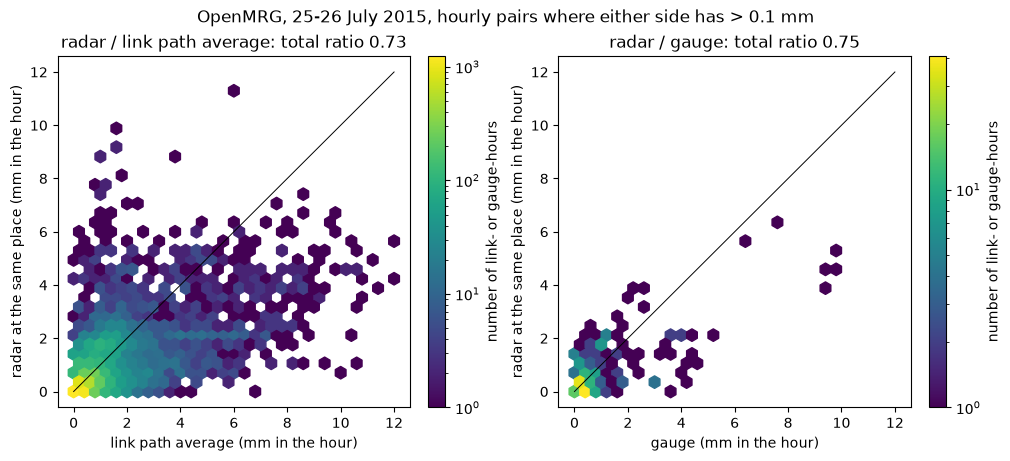

In [3]:
weights = plg.spatial.calc_sparse_intersect_weights_for_several_cmls(
    x1_line=links.x0.values, y1_line=links.y0.values, x2_line=links.x1.values, y2_line=links.y1.values,
    cml_id=links.link.values, x_grid=XG, y_grid=YG, grid_point_location="center")
rad_links = plg.spatial.get_grid_time_series_at_intersections(
    grid_data=radar, intersect_weights=weights).transpose("cml_id", "time").values
rad_gauges = radar.values.reshape(NT, -1)[:, gauge_cell].T          # (station, time)

fig, ax = plt.subplots(1, 2, figsize=(10, 4.5), constrained_layout=True)
for a, obs, rad, what in [(ax[0], links.values, rad_links, "link path average"),
                          (ax[1], gauges.values, rad_gauges, "gauge")]:
    ok = np.isfinite(obs) & np.isfinite(rad) & ((obs > 0.1) | (rad > 0.1))
    hb = a.hexbin(obs[ok], rad[ok], gridsize=30, extent=(0, 12, 0, 12), mincnt=1, bins="log", cmap="viridis")
    fig.colorbar(hb, ax=a, label="number of link- or gauge-hours")
    a.plot([0, 12], [0, 12], "k-", lw=0.7)
    a.set_xlabel(f"{what} (mm in the hour)"); a.set_ylabel("radar at the same place (mm in the hour)")
    a.set_title(f"radar / {what}: total ratio {np.nansum(rad[ok]) / np.nansum(obs[ok]):.2f}")
fig.suptitle("OpenMRG, 25-26 July 2015, hourly pairs where either side has > 0.1 mm");

## 3. Mean-field bias

The simplest adjustment multiplies the whole field by one factor per hour,

$$F_t = \frac{\sum_i o_{i,t}}{\sum_i r_{i,t}}, \qquad \hat R_t(\mathbf{x}) = F_t\, R_t(\mathbf{x}),$$

over the observation-radar pairs $(o_i, r_i)$ of hour $t$. It corrects calibration and Z-R
errors that are uniform over the domain, keeps the radar's pattern exactly, and cannot create
rain the radar missed. With few or dry pairs the factor is noisy, so it is computed only when
the radar sees at least 0.5 mm summed over the pairs, and clipped to $[1/5, 5]$.

In [4]:
def mfb(obs, rad, min_radar=0.5, max_factor=5.0):
    ok = np.isfinite(obs) & np.isfinite(rad)
    so, sr = np.where(ok, obs, 0).sum(0), np.where(ok, rad, 0).sum(0)
    with np.errstate(invalid="ignore", divide="ignore"):
        return np.where(sr >= min_radar, np.clip(so / sr, 1 / max_factor, max_factor), 1.0)


F_links = mfb(links.values, rad_links)
radar_flat = radar.values.reshape(NT, -1)                             # (time, cells)
mfb_links = radar_flat * F_links[:, None]
t_storm = int(np.flatnonzero(links.time.values == np.datetime64(STORM_HOUR))[0])
print(f"mean-field factor from the links in the storm hour: {F_links[t_storm]:.2f}; "
      f"over the 48 h: median {np.median(F_links[F_links != 1]):.2f}")

mean-field factor from the links in the storm hour: 1.56; over the 48 h: median 1.76


## 4. Residual IDW: additive and multiplicative

A spatially varying correction interpolates the observation-radar mismatch to every cell:

$$\text{additive: } \hat R = R + \mathrm{IDW}(o_i - r_i), \qquad
\text{multiplicative: } \hat R = R \cdot \mathrm{IDW}\!\left(\frac{o_i + \epsilon}{r_i + \epsilon}\right).$$

The additive form can create rain where the radar has none and is clipped at zero; the
multiplicative form keeps the radar's dry areas dry but is unstable where the radar is near
zero (hence $\epsilon = 0.5$ mm and a clipped factor). Far from all observations
(> 10 km here) the cell falls back to the mean-field factor, so the field stays complete.
The links enter at their midpoints.

In [5]:
def idw_weights(src_xy, dst_xy, p=2.0, radius=10_000.0):
    d = np.hypot(dst_xy[:, None, 0] - src_xy[None, :, 0], dst_xy[:, None, 1] - src_xy[None, :, 1])
    w = 1.0 / np.maximum(d, 1.0) ** p
    w[d > radius] = 0.0
    return w


def idw_apply(W, values):
    ok = np.isfinite(values)
    num, den = W @ np.where(ok, values, 0.0), W @ ok
    with np.errstate(invalid="ignore", divide="ignore"):
        return np.where(den > 0, num / den, np.nan).T                 # (time, cells)


def residual_idw(obs, rad, obs_xy, kind, eps=0.5, max_factor=5.0):
    W = idw_weights(obs_xy, cells_xy)
    F = mfb(obs, rad)[:, None]
    ok = np.isfinite(obs) & np.isfinite(rad)
    if kind == "add":
        corr = idw_apply(W, np.where(ok, obs - rad, np.nan))
        out = np.clip(radar_flat + corr, 0, None)
    else:
        fac = np.clip(idw_apply(W, np.where(ok, (obs + eps) / (rad + eps), np.nan)), 1 / max_factor, max_factor)
        out = radar_flat * fac
    return np.where(np.isfinite(out), out, radar_flat * F)


add_links = residual_idw(links.values, rad_links, mid_xy, "add")
mul_links = residual_idw(links.values, rad_links, mid_xy, "mul")

`core.maps.merge.adjust(radar, obs, rad_obs, method="mfb" | "add" | "mul")` is the same
computation for any mix of sources on a regular lat/lon grid (it is used in section 8).

## 5. The `mergeplg` methods

`mergeplg` implements the methods compared in the OpenSense radar-adjustment
intercomparison ([radar_adjustment_intercomparison](https://github.com/OpenSenseAction/radar_adjustment_intercomparison)):

* **difference IDW** (`MergeDifferenceIDW`, additive or multiplicative): the residual IDW of
  section 4 with the RADOLAN distance weighting;
* **difference kriging** (`MergeDifferenceOrdinaryKriging`): the additive residual (or the
  ratio) interpolated by ordinary kriging - at the link midpoints (`full_line=False`) or with
  block kriging along the paths (`full_line=True`, tutorial 05 section 7);
* **kriging with external drift** (`MergeKrigingExternalDrift`, KED): the observations are
  kriged with the radar as a linear drift, $\mathrm{E}[Z(\mathbf{x})] = \beta_0 + \beta_1 R(\mathbf{x})$,
  so the radar's pattern and the observations' level are fitted together. Two extra unbiasedness
  constraints (one for each $\beta$) enter the kriging system.

Settings follow the intercomparison: 12 nearest observations, spherical variogram with sill 1,
range 30 km, nugget 0.3. The PyPI release 0.1.0 used here (`.venv`) takes the grid and the
observations as DataArrays with specific coordinate names, and one hour per call. KED in 0.1.0
sets zero-rain cells of the radar it is given to NaN, so it always gets a copy.

In [6]:
from mergeplg import merge as mrg_merge

VARIOGRAM = {"sill": 1.0, "range": 30_000.0, "nugget": 0.3}
da_rad = radar.sel(time=STORM_HOUR).copy()
da_cml = (links.sel(time=STORM_HOUR).rename(link="cml_id")
          .assign_coords(site_0_x=("cml_id", links.x0.values), site_0_y=("cml_id", links.y0.values),
                         site_1_x=("cml_id", links.x1.values), site_1_y=("cml_id", links.y1.values)))
da_cml = da_cml.isel(cml_id=np.flatnonzero(np.isfinite(da_cml.values)))


def run_mergeplg(name, da_cml=da_cml, keep=None):
    """One hour of one mergeplg 0.1.0 method -> flat field."""
    rad = da_rad.copy(deep=True)
    if name in ("idw_add", "idw_mul"):
        m = mrg_merge.MergeDifferenceIDW(min_observations=5)
        out = m.adjust(rad, da_cml=da_cml, nnear=12, method="additive" if name == "idw_add" else "multiplicative",
                       keep_function=keep)
    elif name.startswith("ok"):
        m = mrg_merge.MergeDifferenceOrdinaryKriging(min_observations=5)
        out = m.adjust(rad, da_cml=da_cml, variogram_parameters=VARIOGRAM, nnear=12,
                       full_line=name.endswith("block"),
                       method="multiplicative" if "_mul" in name else "additive", keep_function=keep)
    else:
        m = mrg_merge.MergeKrigingExternalDrift(min_observations=5)
        out = m.adjust(rad, da_cml=da_cml, variogram_parameters=VARIOGRAM, n_closest=12, keep_function=keep)
    return np.clip(np.nan_to_num(np.asarray(out, float).ravel()), 0, None)


MERGEPLG = {"idw_add": "difference IDW, additive", "idw_mul": "difference IDW, multiplicative",
            "ok_add_point": "difference kriging, point", "ok_add_block": "difference kriging, block",
            "ked": "KED, block"}
storm = {label: run_mergeplg(key) for key, label in MERGEPLG.items()}

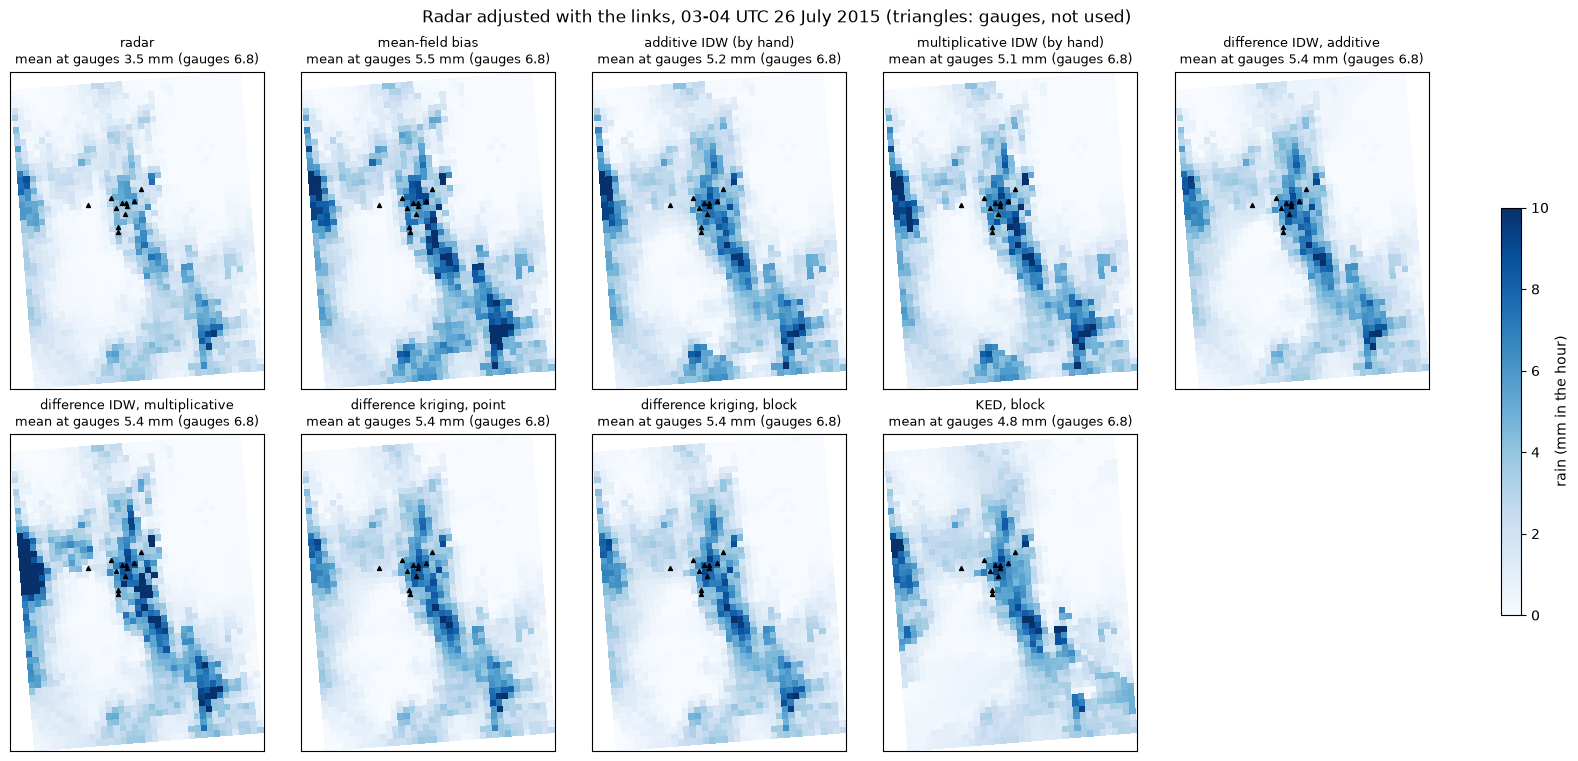

In [7]:
panels = {"radar": radar_flat[t_storm], "mean-field bias": mfb_links[t_storm],
          "additive IDW (by hand)": add_links[t_storm], "multiplicative IDW (by hand)": mul_links[t_storm], **storm}
fig, axes = plt.subplots(2, 5, figsize=(16, 7.5), constrained_layout=True)
for a, (name, field) in zip(axes.ravel(), panels.items()):
    pm = a.pcolormesh(XG / 1e3, YG / 1e3, field.reshape(XG.shape), cmap="Blues", vmin=0, vmax=10, shading="auto")
    a.scatter(gauges.gx / 1e3, gauges.gy / 1e3, c="k", marker="^", s=8)
    vals = field[gauge_cell]
    a.set_title(f"{name}\nmean at gauges {np.nanmean(vals):.1f} mm (gauges {np.nanmean(gauges.values[:, t_storm]):.1f})", fontsize=9)
    a.set_xticks([]); a.set_yticks([]); a.set_aspect("equal")
for a in axes.ravel()[len(panels):]:
    a.axis("off")
fig.colorbar(pm, ax=axes, shrink=0.6, label="rain (mm in the hour)")
fig.suptitle("Radar adjusted with the links, 03-04 UTC 26 July 2015 (triangles: gauges, not used)");

All corrections raise the radar towards the links. KED keeps cells where the radar is zero at
zero (the white holes in its panel): with the radar as drift, no rain is predicted where the
radar sees none. The multiplicative methods also cannot create rain the radar missed, while
the additive ones can.

## 6. Range checks: which pairs to trust

A single link with a stuck baseline, or a radar cell with clutter, produces a mismatch that
any interpolation spreads over its neighbourhood. The intercomparison therefore runs every
method twice, with and without **range checks** that drop implausible pairs before the
correction is interpolated (`range_checks` in `mergeplg`'s current development version):

* `diff_check`: drop a pair if $|o_i - r_i| > 5$ mm;
* `ratio_check`: drop a pair if $o_i / r_i \notin [0.2, 8]$ (only where $r_i > 0$).

The released 0.1.0 has no `range_checks` argument but accepts a `keep_function` that returns
the indices to keep; the function below reproduces the development version's checks. The
difference methods receive `[diff, rad, obs, x0]`, KED `[rad, obs, x0]`.

In [8]:
def range_checks(diff_check=None, ratio_check=None, ked=False):
    def keep(args):
        rad, obs = (args[0], args[1]) if ked else (args[1], args[2])
        usable = np.isfinite(obs) & np.isfinite(rad) & (rad > 0)
        if ked:
            usable &= obs > 0
        flagged = np.zeros_like(usable)
        if diff_check is not None:
            flagged |= np.abs(obs - rad) > diff_check
        if ratio_check is not None:
            with np.errstate(invalid="ignore", divide="ignore"):
                ratio = np.where(rad > 0, obs / rad, np.nan)
            flagged |= (ratio < ratio_check[0]) | (ratio > ratio_check[1])
        return np.flatnonzero(usable & ~flagged)
    return keep


o, r = da_cml.values, rad_links[np.isin(links.link.values, da_cml.cml_id.values), t_storm]
both = np.isfinite(o) & np.isfinite(r) & (r > 0)
with np.errstate(invalid="ignore", divide="ignore"):
    print(f"storm hour, {both.sum()} link-radar pairs with radar > 0: "
          f"diff_check (5 mm) flags {np.sum(both & (np.abs(o - r) > 5))}, "
          f"ratio_check (0.2-8) flags {np.sum(both & ((o / r < 0.2) | (o / r > 8)))}")

checked = {"difference IDW, additive": run_mergeplg("idw_add", keep=range_checks(diff_check=5)),
           "difference IDW, multiplicative": run_mergeplg("idw_mul", keep=range_checks(ratio_check=(0.2, 8))),
           "KED, block": run_mergeplg("ked", keep=range_checks(diff_check=5, ked=True))}
print(pd.DataFrame({name: {"mean at gauges, no check (mm)": np.nanmean(storm[name][gauge_cell]),
                           "mean at gauges, with check (mm)": np.nanmean(f[gauge_cell]),
                           "cells changed by > 0.5 mm": int(np.sum(np.abs(storm[name] - f) > 0.5))}
                    for name, f in checked.items()}).T.round(2).to_string())
print(f"gauges' own mean: {np.nanmean(gauges.values[:, t_storm]):.2f} mm")

storm hour, 352 link-radar pairs with radar > 0: diff_check (5 mm) flags 24, ratio_check (0.2-8) flags 34


                                mean at gauges, no check (mm)  mean at gauges, with check (mm)  cells changed by > 0.5 mm
difference IDW, additive                                 5.37                             4.85                       92.0
difference IDW, multiplicative                           5.43                             5.68                      104.0
KED, block                                               4.80                             4.35                      184.0
gauges' own mean: 6.83 mm


## 7. RADOLAN

[RADOLAN](https://www.dwd.de/DE/leistungen/radolan/radolan.html) is the operational hourly
gauge adjustment of the German weather service (DWD). It turns the radar product RH into the
adjusted RW: the radar is first smoothed with a BOGRA-like filter, additive and multiplicative
corrections are interpolated from the stations with a RADOLAN-specific distance weighting
(exponential decay with range), and a subset of **audit stations** withheld from the
interpolation decides how the corrections are combined. `mergeplg`'s development version
(`main`) has a Python port, `MergeRADOLAN`, that accepts links as well as gauges; the 0.1.0
release in `.venv` does not. FieldSense keeps `main` in a separate environment,
`.venv-mergeplg-main` (set-up commands in `projects/maps/archive_pipeline/README.md`), and runs
RADOLAN there in `projects/maps/archive_pipeline` and `projects/maps/radar_adjustment`. The cell below
runs it if the kernel has it:

In [9]:
if hasattr(mrg_merge, "MergeRADOLAN"):
    ds_rad = da_rad.astype("float64")
    m = mrg_merge.MergeRADOLAN(ds_rad=ds_rad, ds_cmls=da_cml.astype("float64"), nnear=8, max_distance=60_000)
    out = m(ds_rad, da_cmls=da_cml.astype("float64"), start_index_in_relevant_stations=0)
    radolan = np.asarray(out["RW_not_rounded"] if isinstance(out, xr.Dataset) else out).ravel()
    print(f"RADOLAN, storm hour: mean at gauges {np.nanmean(radolan[gauge_cell]):.2f} mm")
else:
    print(f"mergeplg {__import__('mergeplg').__version__} has no MergeRADOLAN; "
          "run this notebook with the .venv-mergeplg-main kernel to include it.")

mergeplg 0.1.0 has no MergeRADOLAN; run this notebook with the .venv-mergeplg-main kernel to include it.


## 8. Which sensors, merged how? An honest comparison

Scoring a merged map at gauges it was built from rewards over-fitting. The rules here:

* when the **links** or the **weather stations** adjust the radar, all 11 official gauges are
  independent and every product is scored at all of them;
* when **gauges** adjust the radar, each gauge is held out in turn (leave-one-out): the
  product is rebuilt from the other ten and scored at the held-out one, hour by hour.

For speed this section uses `core.maps.mergeplg_methods.Merger`, FieldSense's vectorised port
of the `mergeplg` 0.1.0 methods. It computes the geometry once, evaluates a method at any set
of cells, and can leave observations out (`obs_mask`) without rebuilding anything;
`tests/test_merging.py` checks it against `mergeplg`'s own `adjust()`. It works on a
regular latitude/longitude grid, so the radar is first resampled to 0.02 deg with
`core.opensense.networks.regrid`. The variogram's shape is fitted to the radar fields
themselves (`fit_radar_variogram`), which uses no gauge. The simpler methods come from
`core.maps.merge`.

In [10]:
from core.geo import Domain, Grid
from core.maps import merge as cm
from core.maps.idw import idw_map
from core.maps.mergeplg_methods import Merger, fit_radar_variogram
from core.opensense.networks import regrid

grid = Grid.from_domain(Domain.around(radar.lat.values, radar.lon.values, pad_deg=0.0), res_deg=0.02)
radar_ll = xr.DataArray(regrid(radar.values.reshape(NT, -1), radar.lat.values, radar.lon.values, grid),
                        dims=("time", "lat", "lon"), coords={"time": radar.time.values, "lat": grid.lat, "lon": grid.lon})
variogram = fit_radar_variogram(radar_ll)
print("radar variogram:", {k: round(v, 2) if isinstance(v, float) else v for k, v in variogram.items()})

gauges_ll = gauges.drop_vars(["gx", "gy"])
links_ll = links.drop_vars(["x0", "y0", "x1", "y1", "xm", "ym"])
ll_cells = Merger(radar_ll, gauges=gauges_ll).cells_at(gauges.lat.values, gauges.lon.values)

radar variogram: {'sill': 1.0, 'range': 53413.04, 'nugget': 0.12, 'fitted': True, 'hours': 26}


### 8.1 Optional: personal weather stations

The OpenMRG2 preview adds 30 Netatmo PWS over Gothenburg (5-min amounts). PWS are dense and
free but some are faulty, so they pass the PWSQC filters of de Vos et al. (2019) first
(`pypwsqc`, wrapped in `core.opensense.pws_qc`): **FZ** flags runs of zeros while the
neighbours report rain, **HI** flags far more rain than the neighbours. (The third filter,
station outlier, needs four weeks of record and is not evaluated on this window.) The file is
not part of the example subsets; fetch it with `python -m core.opensense.fetch --dataset
openmrg2_pws`. Without it, the PWS rows of the table are skipped.

In [11]:
from core.opensense.networks import NETWORKS

pws_hourly = None
if (NETWORKS["openmrg"].PWS / "OpenMRGplus_rain.nc").exists():
    from core.opensense import pws_qc
    raw = NETWORKS["openmrg"].points("2015-07-22", "2015-07-30", sets=["pws"])["pws"]
    px, py = plg.spatial.project_point_coordinates(raw.lon, raw.lat, "EPSG:32632")
    ds = xr.Dataset({"rainfall": raw.rain.rename(station="id")},
                    coords={"lon": ("id", raw.lon.values), "lat": ("id", raw.lat.values),
                            "x": ("id", np.asarray(px)), "y": ("id", np.asarray(py))})
    qc = pws_qc.flag(ds)
    print(pws_qc.summary(qc)[["missing", "fz", "hi", "total_mm", "total_qc_mm"]].round(2).tail(8).to_string())
    amount = qc.rainfall_qc.rename(id="station")
    r = amount.resample(time="1h", label="right", closed="right")
    pws_hourly = r.sum(min_count=1).where(r.count() >= 10).sel(time=links.time)   # >= 10 of 12 steps
    pws_hourly = pws_hourly.assign_coords(lat=("station", raw.lat.values), lon=("station", raw.lon.values))
    print(f"{pws_hourly.sizes['station']} PWS, {int(pws_hourly.notnull().sum())} usable station-hours")
else:
    print("OpenMRG2 PWS not found - skipping the PWS products.")

         missing   fz   hi   total_mm  total_qc_mm
station                                           
pws_19       0.0  0.0  0.0  48.700001    48.700001
pws_15       0.0  0.0  0.0  51.310001    51.310001
pws_20       0.0  0.0  0.0  51.310001    51.310001
pws_29       0.0  0.0  0.0  64.940002    64.940002
pws_2        0.0  0.0  0.0  65.059998    65.059998
pws_14       0.0  0.0  0.0  65.440002    65.440002
pws_13       0.0  0.0  0.0  73.019997    73.019997
pws_21       0.0  0.0  0.0  80.029999    80.029999
30 PWS, 1420 usable station-hours


### 8.2 Building and scoring every product

In [12]:
def at_gauges_all(field_ll):
    """(time, lat, lon) -> (station, time) at the gauges' cells."""
    return field_ll.values.reshape(NT, -1)[:, ll_cells].T


def obs_and_rad(**sources):
    obs, rad = cm.observations(radar_ll, **sources)
    return obs, rad


products = {"radar alone": at_gauges_all(radar_ll)}
products["links alone (IDW)"] = at_gauges_all(idw_map(links_ll, grid, radius_m=10_000))

# --- adjusted with independent sources: links, PWS, both -> scored at every gauge
sources = {"links": dict(links=links_ll)}
if pws_hourly is not None:
    sources["PWS"] = dict(gauges=pws_hourly)
    sources["links + PWS"] = dict(links=links_ll, gauges=pws_hourly)
for src, kw in sources.items():
    obs, rad = obs_and_rad(**{("cml" if k == "links" else "pws"): v for k, v in kw.items()})
    for method in ("mfb", "add", "mul"):
        products[f"radar + {src}: {dict(mfb='mean-field bias', add='additive IDW', mul='multiplicative IDW')[method]}"] = \
            at_gauges_all(cm.adjust(radar_ll, obs, rad, method=method))
    M = Merger(radar_ll, variogram=variogram, **kw)
    for method, label in [("idw_add", "difference IDW (add.)"), ("okrig_add", "difference block kriging"), ("ked", "KED")]:
        products[f"radar + {src}: {label}"] = M.adjust(method, cells=ll_cells).T

# --- adjusted with the gauges themselves (or gauges + links): leave one gauge out
n_g = gauges.sizes["station"]
for src, kw in [("gauges", dict(gauges=gauges_ll)), ("links + gauges", dict(links=links_ll, gauges=gauges_ll))]:
    M = Merger(radar_ll, variogram=variogram, **kw)
    n_links = links_ll.sizes["link"] if "links" in kw else 0
    loo = {k: np.full((n_g, NT), np.nan) for k in ("mfb", "add", "idw_add", "okrig_add", "ked")}
    for s in range(n_g):
        keep_g = np.arange(n_g) != s
        mask = np.r_[np.ones(n_links, bool), keep_g]
        cell = ll_cells[[s]]
        for method in ("idw_add", "okrig_add", "ked"):
            loo[method][s] = M.adjust(method, cells=cell, obs_mask=mask)[:, 0]
        o_kw = {"gauges" if k == "gauges" else "cml": (v.isel(station=np.flatnonzero(keep_g)) if k == "gauges" else v)
                for k, v in kw.items()}
        obs, rad = obs_and_rad(**o_kw)
        for method in ("mfb", "add"):
            loo[method][s] = at_gauges_all(cm.adjust(radar_ll, obs, rad, method=method))[s]
    names = {"mfb": "mean-field bias", "add": "additive IDW", "idw_add": "difference IDW (add.)",
             "okrig_add": "difference block kriging", "ked": "KED"}
    for k, v in loo.items():
        products[f"radar + {src} (held out): {names[k]}"] = v

# --- gauges alone, held out
W = idw_weights(g_xy, g_xy, radius=30_000)
gauge_only = np.full((n_g, NT), np.nan)
for s in range(n_g):
    w = W[s].copy(); w[s] = 0
    gauge_only[s] = idw_apply(w[None, :], gauges.values)[:, 0]
products["gauges alone (IDW, held out)"] = gauge_only


def row(est):
    m = plg.validation.calculate_rainfall_metrics(reference=gauges.values.ravel(), estimate=np.asarray(est).ravel())
    return {"RMSE (mm)": m["root_mean_square_error"], "corr": m["pearson_correlation_coefficient"],
            "bias (%)": m["percent_bias"], "gauge-hours": int(m["N_all"] - m["N_nan"])}


table = pd.DataFrame({k: row(v) for k, v in products.items()}).T
table.round(2)

,RMSE (mm),corr,bias (%),gauge-hours
radar alone,1.00,0.75,-24.36,528.0
links alone (IDW),0.68,0.89,9.68,528.0
radar + links: mean-field bias,0.83,0.82,2.38,528.0
radar + links: additive IDW,0.66,0.89,10.80,528.0
radar + links: multiplicative IDW,0.69,0.89,-6.57,528.0
radar + links: difference IDW (add.),0.62,0.91,7.35,528.0
radar + links: difference block kriging,0.61,0.91,6.02,528.0
radar + links: KED,0.63,0.91,0.12,528.0
radar + PWS: mean-field bias,0.81,0.83,-13.91,528.0
radar + PWS: additive IDW,0.81,0.84,-14.69,528.0


### 8.3 Reading the result

One event and 11 gauges: this shows how to compare, not which method is best in general.
On this event:

* **The radar alone reads about a quarter low at the gauges** (bias about -24%, RMSE 1.0 mm).
  A single mean-field factor from the links removes the bias but not the scatter (RMSE 0.83).
* **Spatially varying corrections with the links do best** (difference IDW, block kriging, KED:
  RMSE about 0.6 mm, correlation 0.91); KED is the only one without a bias. They improve only
  a little on the links alone (0.68): in Gothenburg the link network is dense and close to
  the gauges, so the links carry most of the information.
* **The PWS adjust the radar's level but read low themselves** (about -14% after adjustment).
  This is the known under-catch of Netatmo gauges, which an operational chain corrects with a
  bias factor (de Vos et al. 2019). Adding them to the links changes little.
* **Gauges as adjusters, held out**: ten gauges improve the radar (additive IDW 0.69) but less
  than the 353 links. Adding the links to the gauges brings the result to the links' level.
  The `gauge-hours` column shows that every product is scored on the same pairs, except the
  gauge-only map, which also covers the few hours where the radar is missing.

At scale - three networks, ten storms each, seven methods, five-fold held-out gauges - this
comparison is `projects/maps/multisensor` (`run.py merge`); `projects/maps/radar_adjustment`
replicates the OpenSense intercomparison (16 method variants, with and without range checks,
over whole summers) and adds weather stations as adjusters.

## Summary

* Adjustment keeps the radar's pattern and takes the amount from the ground. Mean-field bias
  corrects the domain-wide error, residual interpolation (IDW, kriging) a spatially varying
  one, KED fits both together.
* Links are compared with the radar averaged along their path, gauges with their cell.
* Range checks keep single bad pairs from spreading through the correction.
* Score only at gauges a product did not use.

Next: **tutorial 07** forecasts these fields a short time ahead with pysteps.

## References and links

* Andersson, J. C. M., et al. (2022): OpenMRG. *Earth Syst. Sci. Data*, 14, 5411-5426,
  [doi:10.5194/essd-14-5411-2022](https://doi.org/10.5194/essd-14-5411-2022).
* de Vos, L. W., Leijnse, H., Overeem, A. and Uijlenhoet, R. (2019): Quality control for
  crowdsourced personal weather stations to enable operational rainfall monitoring.
  *Geophys. Res. Lett.*, 46, 8820-8829, [doi:10.1029/2019GL083731](https://doi.org/10.1029/2019GL083731).
* Goudenhoofdt, E. and Delobbe, L. (2009): Evaluation of radar-gauge merging methods for
  quantitative precipitation estimates. *Hydrol. Earth Syst. Sci.*, 13, 195-203,
  [doi:10.5194/hess-13-195-2009](https://doi.org/10.5194/hess-13-195-2009).
* DWD RADOLAN: [dwd.de/radolan](https://www.dwd.de/DE/leistungen/radolan/radolan.html).
* Software: [mergeplg](https://github.com/OpenSenseAction/mergeplg),
  [poligrain](https://github.com/OpenSenseAction/poligrain),
  [pypwsqc](https://github.com/OpenSenseAction/pypwsqc),
  [wradlib adjustment](https://docs.wradlib.org/en/latest/adjust.html).
* OpenSense: [radar_adjustment_intercomparison](https://github.com/OpenSenseAction/radar_adjustment_intercomparison),
  [TrainingSchoolMergingApplication](https://github.com/OpenSenseAction/TrainingSchoolMergingApplication)
  (notebooks `os-merging-session/5_step_by_step_radar_adjustment.ipynb` to `7_openrainer_comparison.ipynb`),
  [OpenSense software](https://opensenseaction.github.io).
* FieldSense projects: [`multisensor_maps`](../projects/maps/multisensor/),
  [`opensense_pipeline`](../projects/maps/archive_pipeline/),
  [`radar_adjustment`](../projects/maps/radar_adjustment/).